# Image Quality Metric Extraction – ARCADE

No-Reference (NR-IQA) metrics on ARCADE coronary X-ray images.
Produces `quality_metrics.csv` with per-image scores.

| Category | Metrics | Direction |
|----------|---------|-----------|
| Sharpness (classical) | Laplacian Var, Tenengrad, Brenner | ↑ = sharper |
| Contrast | RMS, Michelson | ↑ = more contrast |
| Exposure | Mean Brightness | mid-range = well exposed |
| Noise (classical) | Immerkaer σ, Wavelet σ | ↓ = less noise |
| NR-IQA classical | BRISQUE, NIQE (piq) | ↓ = better quality |
| NR-IQA deep | CLIP-IQA (piq) | ↑ = better quality |
| Composite | quality_score | ↑ = better quality |

In [30]:
import subprocess, sys
for pkg in ['piq', 'opencv-python', 'tqdm', 'seaborn', 'PyWavelets']:
    try:
        __import__(pkg.replace('-','_').replace('PyWavelets','pywt').replace('opencv_python','cv2'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencies OK')

Dependencies OK


In [31]:
import os, glob, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
import cv2, pywt
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

try:
    import piq
    PIQ_AVAILABLE = True
    print(f'piq {piq.__version__}')
except ImportError:
    PIQ_AVAILABLE = False
    print('WARNING: piq not available – BRISQUE/NIQE/CLIP-IQA disabled')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

piq 0.8.0
Device: cuda


In [32]:
import os
from pathlib import Path

# Chemin relatif depuis le notebook vers le dataset à la racine du projet
DATASET_PATH = str((Path(os.path.abspath('')) / '../../arcade_challenge_datasets').resolve())

RESULTS_DIR = '../outputs'
os.makedirs(RESULTS_DIR, exist_ok=True)
METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')
os.makedirs(METRICS_DIR, exist_ok=True)
OUTPUT_CSV = os.path.join(METRICS_DIR, 'quality_metrics_scores.csv')
MIN_SIZE   = 64
IMG_EXT    = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']

In [33]:
def get_image_paths(root):
    # Only scan 'images/' subdirectories to exclude annotation masks
    paths = []
    for ext in IMG_EXT:
        paths += glob.glob(os.path.join(root, '**', 'images', f'*{ext}'), recursive=True)
        paths += glob.glob(os.path.join(root, '**', 'images', f'*{ext.upper()}'), recursive=True)
    return sorted(set(paths))

image_paths = get_image_paths(DATASET_PATH)
print(f'Images found: {len(image_paths)}')

Images found: 3000


In [34]:
def load_gray(path):
    buf = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    if img is None: raise IOError(f'Cannot decode: {path}')
    return img.astype(np.float32) / 255.0

def load_tensor(path, rgb=False):
    img = Image.open(path).convert('RGB' if rgb else 'L')
    return T.ToTensor()(img).unsqueeze(0)  # (1, C, H, W)

In [35]:
def laplacian_variance(img):
    return float(np.var(cv2.Laplacian((img * 255).astype(np.uint8), cv2.CV_64F)))

def tenengrad(img, ksize=3):
    i8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    Gx = cv2.Sobel(i8, cv2.CV_64F, 1, 0, ksize=ksize)
    Gy = cv2.Sobel(i8, cv2.CV_64F, 0, 1, ksize=ksize)
    return float(np.mean(Gx**2 + Gy**2))

def brenner(img):
    return float(np.mean((img[2:, :] - img[:-2, :])**2))

In [36]:
def rms_contrast(img):    return float(np.std(img))

def michelson(img):
    hi, lo = np.max(img), np.min(img)
    return float((hi - lo) / (hi + lo + 1e-8))

def mean_brightness(img): return float(np.mean(img))

In [37]:
def immerkaer_noise(img):
    """Immerkaer 1996 – noise sigma estimation via Laplacian filter."""
    H, W = img.shape
    K = np.array([[1,-2,1],[-2,4,-2],[1,-2,1]], dtype=np.float64)
    filtered = cv2.filter2D((img * 255).astype(np.float64), -1, K)
    return float(np.sum(np.abs(filtered)) * np.sqrt(0.5 * np.pi) / (6 * (W-2) * (H-2)))

def wavelet_noise(img):
    """Donoho & Johnstone 1994 – MAD on Haar DWT HH subband."""
    _, (_, _, HH) = pywt.dwt2(img, 'haar')
    return float(np.median(np.abs(HH)) / 0.6745)

In [38]:
def _t3(path):
    """Load image and repeat grayscale channel 3x (required by piq)."""
    return load_tensor(path, rgb=False).repeat(1, 3, 1, 1)

def compute_brisque(path):
    if not PIQ_AVAILABLE: return None
    try:
        with torch.no_grad():
            return float(piq.brisque(_t3(path), data_range=1.0, reduction='none').item())
    except Exception:
        return None

def compute_niqe(path):
    if not PIQ_AVAILABLE: return None
    try:
        with torch.no_grad():
            return float(piq.NIQE()(_t3(path)).item())
    except Exception:
        return None

_clip_model = None
def _get_clip():
    global _clip_model
    if _clip_model is None and PIQ_AVAILABLE:
        try: _clip_model = piq.CLIPIQA().to(DEVICE).eval()
        except Exception as e: print(f'CLIP-IQA unavailable: {e}')
    return _clip_model

def compute_clip_iqa(path):
    m = _get_clip()
    if m is None: return None
    try:
        with torch.no_grad():
            return float(m(load_tensor(path, rgb=True).to(DEVICE)).item())
    except Exception:
        return None

_get_clip()  # pre-load model

CLIPIQA(
  (feature_extractor): CLIP(
    (visual): ModifiedResNet(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (avgpool): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (relu): ReLU(inplace=True)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3

In [39]:
def compute_all(path):
    row = {
        'image_path': path,
        'filename':   os.path.basename(path),
        'subset':     os.path.basename(os.path.dirname(os.path.dirname(path))),
    }
    try:
        img = load_gray(path)
        H, W = img.shape
        row.update({'height': H, 'width': W})
        if H < MIN_SIZE or W < MIN_SIZE:
            row['error'] = f'too small ({W}x{H})'
            return row

        row['laplacian_var']   = laplacian_variance(img)
        row['tenengrad']       = tenengrad(img)
        row['brenner']         = brenner(img)
        row['rms_contrast']    = rms_contrast(img)
        row['michelson']       = michelson(img)
        row['mean_brightness'] = mean_brightness(img)
        row['immerkaer_noise'] = immerkaer_noise(img)
        row['wavelet_noise']   = wavelet_noise(img)
        row['brisque']         = compute_brisque(path)
        row['niqe']            = compute_niqe(path)
        row['clip_iqa']        = compute_clip_iqa(path)
    except Exception as e:
        row['error'] = str(e)
    return row

In [40]:
results = [compute_all(p) for p in tqdm(image_paths, desc='Computing metrics')]
df = pd.DataFrame(results)
n_err = df['error'].notna().sum() if 'error' in df.columns else 0
print(f'Processed: {len(df)}  |  Errors: {n_err}')
df.head()

Computing metrics:   0%|          | 0/3000 [00:00<?, ?it/s]

Computing metrics: 100%|██████████| 3000/3000 [04:15<00:00, 11.75it/s]

Processed: 3000  |  Errors: 0


,image_path,filename,subset,height,width,laplacian_var,tenengrad,brenner,rms_contrast,michelson,mean_brightness,immerkaer_noise,wavelet_noise,brisque,niqe,clip_iqa
0,/home/elias/telecom/2a/ima/im06/Project/projet...,1.png,test_case_segmentation,512,512,248.077652,4910.734589,0.002252,0.196836,1.0,0.583556,1.665012,0.008721,6.465759,None,0.224059
1,/home/elias/telecom/2a/ima/im06/Project/projet...,10.png,test_case_segmentation,512,512,380.023432,5535.256195,0.004002,0.179239,1.0,0.525190,1.996428,0.008721,1.175598,None,0.251386
2,/home/elias/telecom/2a/ima/im06/Project/projet...,100.png,test_case_segmentation,512,512,583.278407,3831.077682,0.002074,0.253150,1.0,0.543558,1.257065,0.005814,15.744934,None,0.260436
3,/home/elias/telecom/2a/ima/im06/Project/projet...,101.png,test_case_segmentation,512,512,124.923988,2367.333344,0.001442,0.145710,1.0,0.364166,1.188340,0.005814,10.711060,None,0.203455
4,/home/elias/telecom/2a/ima/im06/Project/projet...,102.png,test_case_segmentation,512,512,107.128692,1772.221672,0.001061,0.155337,1.0,0.549621,1.312238,0.005814,14.327026,None,0.156872


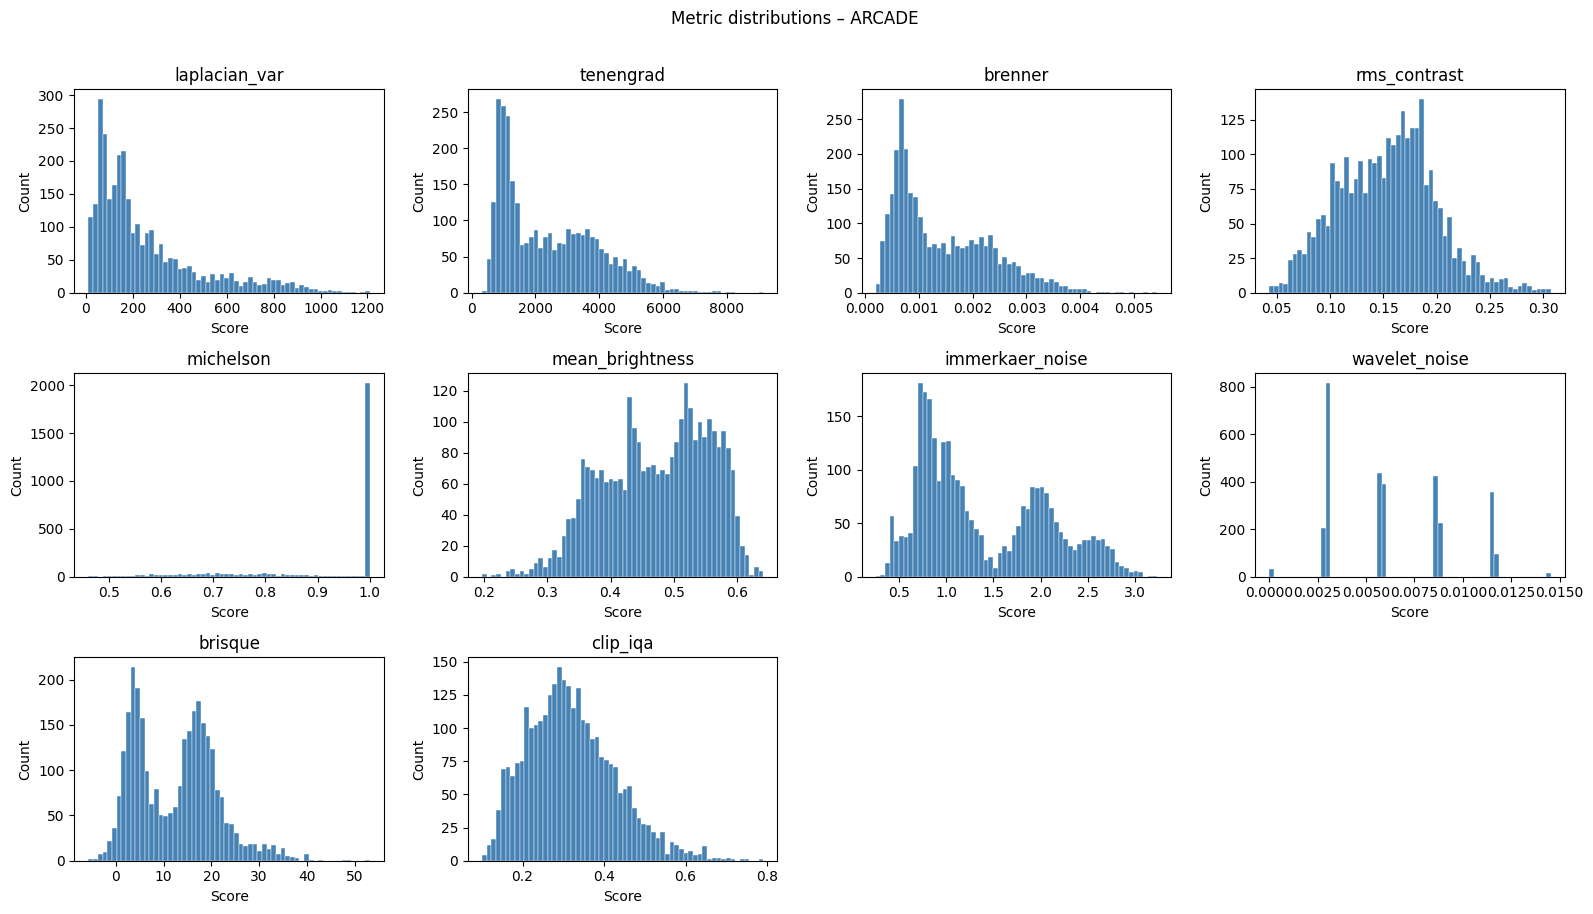

In [41]:
METRIC_COLS = ['laplacian_var','tenengrad','brenner','rms_contrast',
               'michelson','mean_brightness','immerkaer_noise',
               'wavelet_noise','brisque','niqe','clip_iqa']
avail = [c for c in METRIC_COLS if c in df.columns and df[c].notna().any()]

if not avail:
    print('No metric data available to plot')
else:
    ncols = 4
    nrows = max(1, -(-len(avail) // ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
    axes = axes.flatten()
    for i, col in enumerate(avail):
        axes[i].hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='white', lw=0.3)
        axes[i].set_title(col); axes[i].set_xlabel('Score'); axes[i].set_ylabel('Count')
    for j in range(len(avail), len(axes)): axes[j].set_visible(False)
    plt.suptitle('Metric distributions – ARCADE', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'quality_distributions.png'), dpi=150, bbox_inches='tight')
    plt.show()

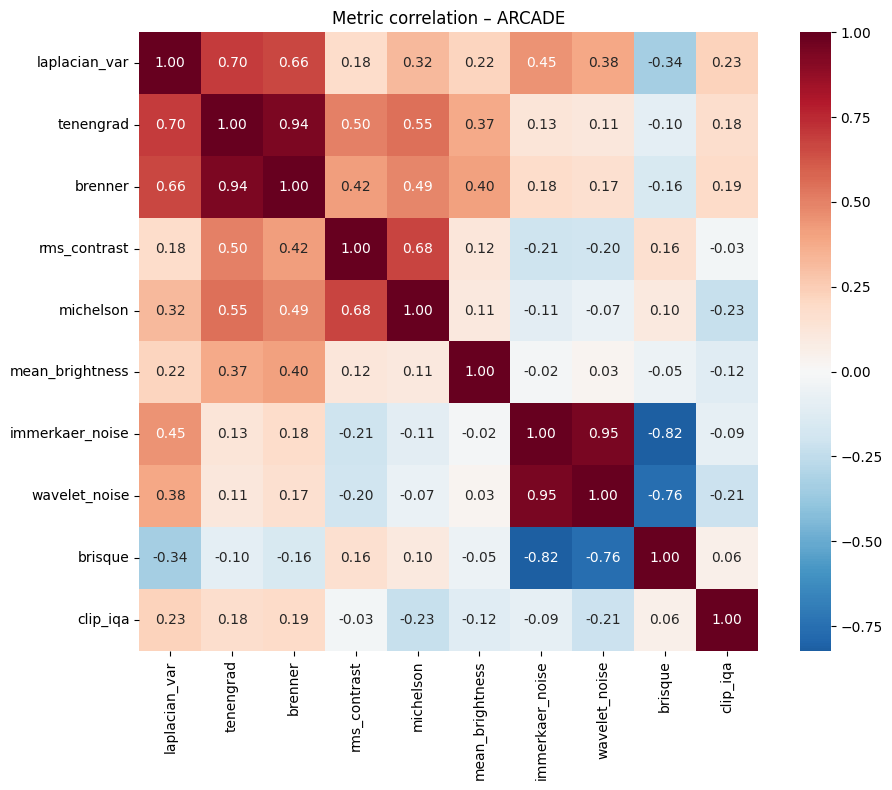

In [42]:
corr = df[avail].dropna().corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Metric correlation – ARCADE')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'quality_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

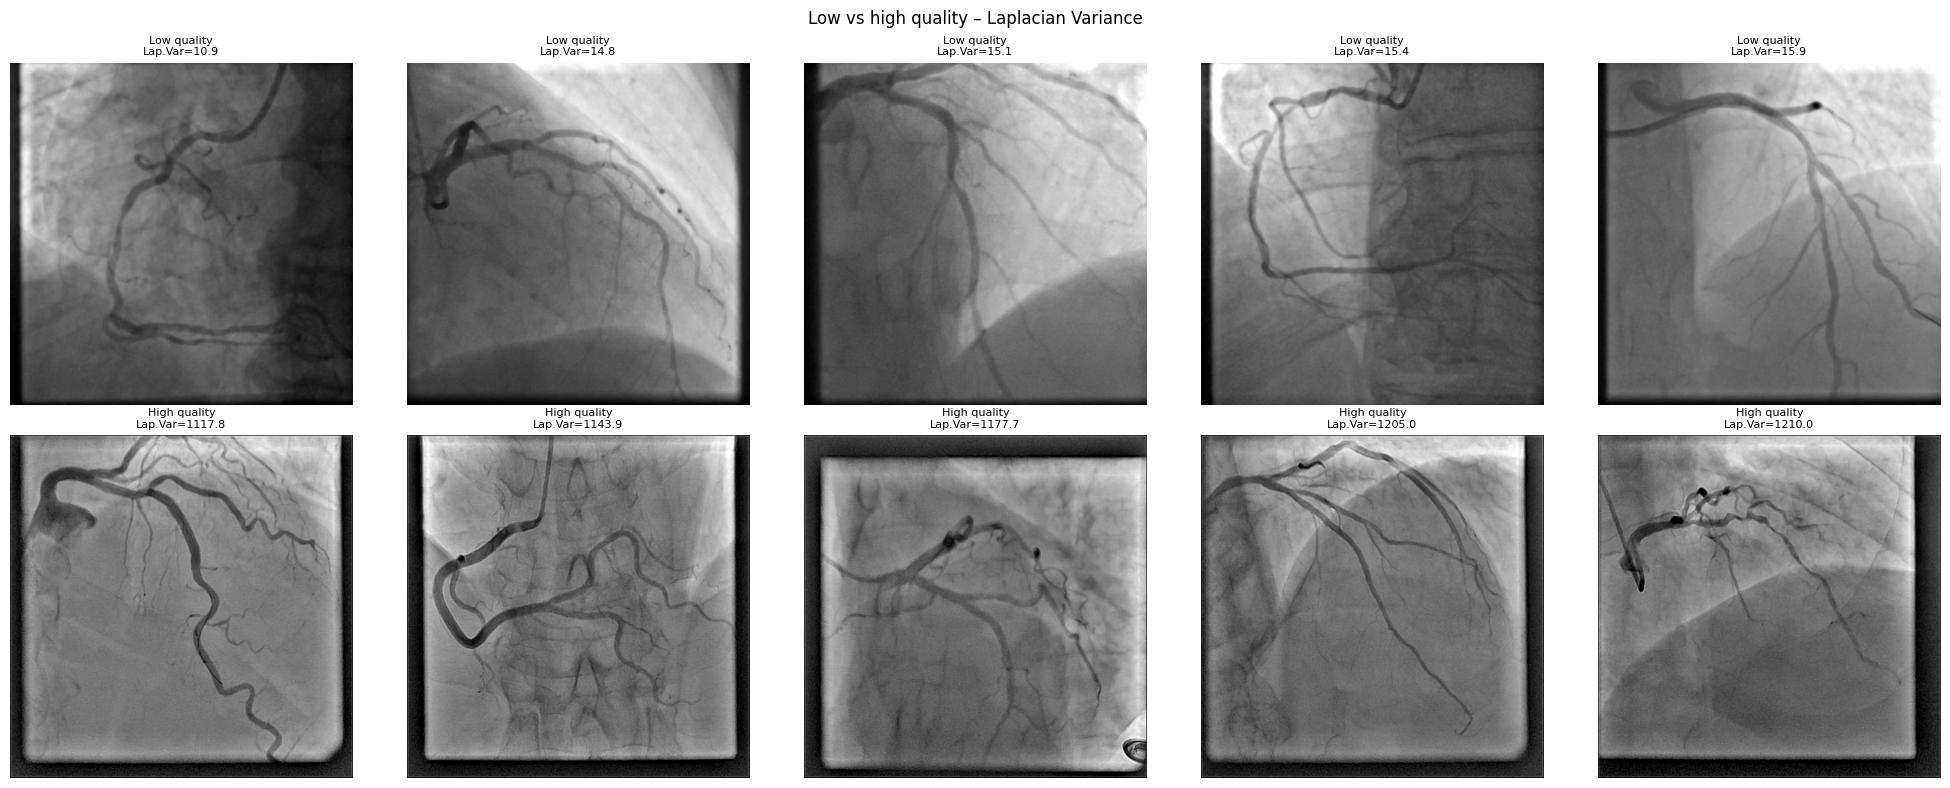

In [43]:
df_v = df[df['laplacian_var'].notna()]
ds = df_v.sort_values('laplacian_var')

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ri, (paths, label) in enumerate([
        (ds['image_path'].iloc[:5].tolist(), 'Low quality'),
        (ds['image_path'].iloc[-5:].tolist(), 'High quality')]):
    for ci, p in enumerate(paths):
        ax = axes[ri, ci]
        try:
            img = (load_gray(p) * 255).astype(np.uint8)
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        except Exception:
            pass
        score = df.loc[df['image_path'] == p, 'laplacian_var'].values[0]
        ax.set_title(f'{label}\nLap.Var={score:.1f}', fontsize=8)
        ax.axis('off')
plt.suptitle('Low vs high quality – Laplacian Variance')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'quality_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

Composite score added – ../outputs/metrics/quality_metrics_scores.csv


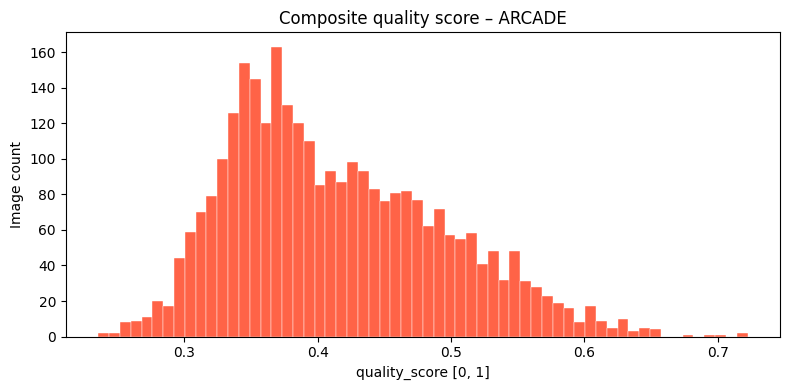

In [44]:
def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-8)

components = {}
for c in ['laplacian_var', 'rms_contrast', 'tenengrad']:  # high = good
    if c in df: components[c] = minmax(df[c])
for c in ['immerkaer_noise', 'brisque', 'niqe']:           # low = good
    if c in df: components[c] = 1 - minmax(df[c])
if 'clip_iqa' in df: components['clip_iqa'] = minmax(df['clip_iqa'])

df['quality_score'] = pd.DataFrame(components).mean(axis=1)
df[['filename', 'quality_score']].to_csv(OUTPUT_CSV, index=False)
print(f'Composite score added – {OUTPUT_CSV}')

plt.figure(figsize=(8, 4))
plt.hist(df['quality_score'].dropna(), bins=60, color='tomato', edgecolor='white', lw=0.3)
plt.xlabel('quality_score [0, 1]'); plt.ylabel('Image count')
plt.title('Composite quality score – ARCADE')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'quality_composite.png'), dpi=150, bbox_inches='tight')
plt.show()